This example is from keras.io/examples/generative/vae

Attribution given to the orginal author: 

Variational AutoEncoder
Author: fchollet
Date created: 2020/05/03
Last modified: 2023/11/22
Description: Convolutional Variational AutoEncoder (VAE) trained on MNIST digits.

Setup the Keras Environment

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import numpy as np
import tensorflow as tf
import keras
from keras import layers
import matplotlib.pyplot as plt

Create a Sampling Layer

In [2]:
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = tf.shape(z_mean)[0]
        dim = tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

Construct the Encoder

In [3]:
latent_dim = 3

encoder_inputs = keras.Input(shape=(28, 28, 1))
x = layers.Conv2D(32, 3, activation="relu", strides=2, padding="same")(encoder_inputs)
x = layers.Conv2D(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Flatten()(x)
x = layers.Dense(16, activation="relu")(x)
z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(encoder_inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


Model: "encoder"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, 14, 14, 32)           320       ['input_1[0][0]']             
                                                                                                  
 conv2d_1 (Conv2D)           (None, 7, 7, 64)             18496     ['conv2d[0][0]']              
                                                                                                  
 flatten (Flatten)           (None, 3136)                 0         ['conv2d_1[0][0]']            
                                                                                           

Construct the Decoder

In [4]:
latent_inputs = keras.Input(shape=(latent_dim,))
x = layers.Dense(7 * 7 * 64, activation="relu")(latent_inputs)
x = layers.Reshape((7, 7, 64))(x)
x = layers.Conv2DTranspose(64, 3, activation="relu", strides=2, padding="same")(x)
x = layers.Conv2DTranspose(32, 3, activation="relu", strides=2, padding="same")(x)
decoder_outputs = layers.Conv2DTranspose(1, 3, activation="sigmoid", padding="same")(x)
decoder = keras.Model(latent_inputs, decoder_outputs, name="decoder")
decoder.summary()

Model: "decoder"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 3)]               0         
                                                                 
 dense_1 (Dense)             (None, 3136)              12544     
                                                                 
 reshape (Reshape)           (None, 7, 7, 64)          0         
                                                                 
 conv2d_transpose (Conv2DTr  (None, 14, 14, 64)        36928     
 anspose)                                                        
                                                                 
 conv2d_transpose_1 (Conv2D  (None, 28, 28, 32)        18464     
 Transpose)                                                      
                                                                 
 conv2d_transpose_2 (Conv2D  (None, 28, 28, 1)         289 

Define the VAE as a Class with Custom Training

In [5]:
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")

    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data)
            reconstruction = self.decoder(z)
            reconstruction_loss = tf.reduce_mean(
                tf.reduce_sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - tf.square(z_mean) - tf.exp(z_log_var))
            kl_loss = tf.reduce_mean(tf.reduce_sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }

Train the Model

In [6]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digit_labels = np.concatenate([y_train, y_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

In [7]:
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()
mnist_digits = np.concatenate([x_train, x_test], axis=0)
mnist_digits = np.expand_dims(mnist_digits, -1).astype("float32") / 255

vae = VAE(encoder, decoder)
vae.compile(optimizer=keras.optimizers.Adam())
history = vae.fit(mnist_digits, epochs=30, batch_size=128)

Epoch 1/30
547/547 [==============================] - 36s 57ms/step - loss: 254.3623 - reconstruction_loss: 205.7332 - kl_loss: 3.7351
Epoch 2/30
547/547 [==============================] - 34s 61ms/step - loss: 176.5418 - reconstruction_loss: 167.6042 - kl_loss: 5.9189
Epoch 3/30
547/547 [==============================] - 42s 77ms/step - loss: 167.7018 - reconstruction_loss: 160.1483 - kl_loss: 6.1696
Epoch 4/30
547/547 [==============================] - 37s 67ms/step - loss: 158.7951 - reconstruction_loss: 147.5655 - kl_loss: 7.8851
Epoch 5/30
547/547 [==============================] - 38s 70ms/step - loss: 149.7916 - reconstruction_loss: 140.3806 - kl_loss: 8.3653
Epoch 6/30
547/547 [==============================] - 32s 58ms/step - loss: 146.5965 - reconstruction_loss: 137.6060 - kl_loss: 8.4622
Epoch 7/30
547/547 [==============================] - 34s 63ms/step - loss: 144.6689 - reconstruction_loss: 135.8251 - kl_loss: 8.4970
Epoch 8/30
547/547 [==============================] - 3

Plot the Loss Functions

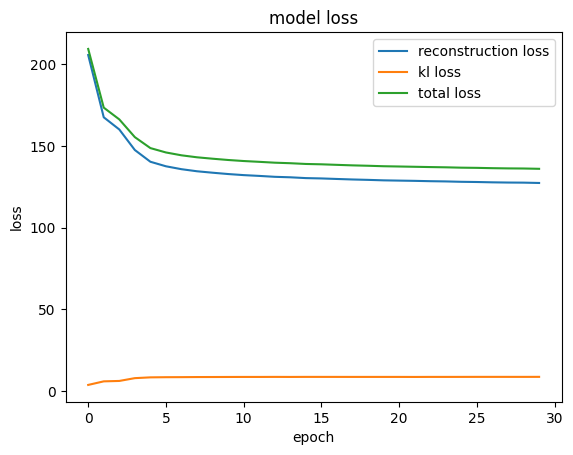

In [8]:
# summarize history for accuracy
plt.plot(history.history['reconstruction_loss'])
plt.plot(history.history['kl_loss'])
plt.plot(history.history['loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['reconstruction loss', 'kl loss', 'total loss'], loc='upper right')
plt.show()

Display a grid of sampled digits

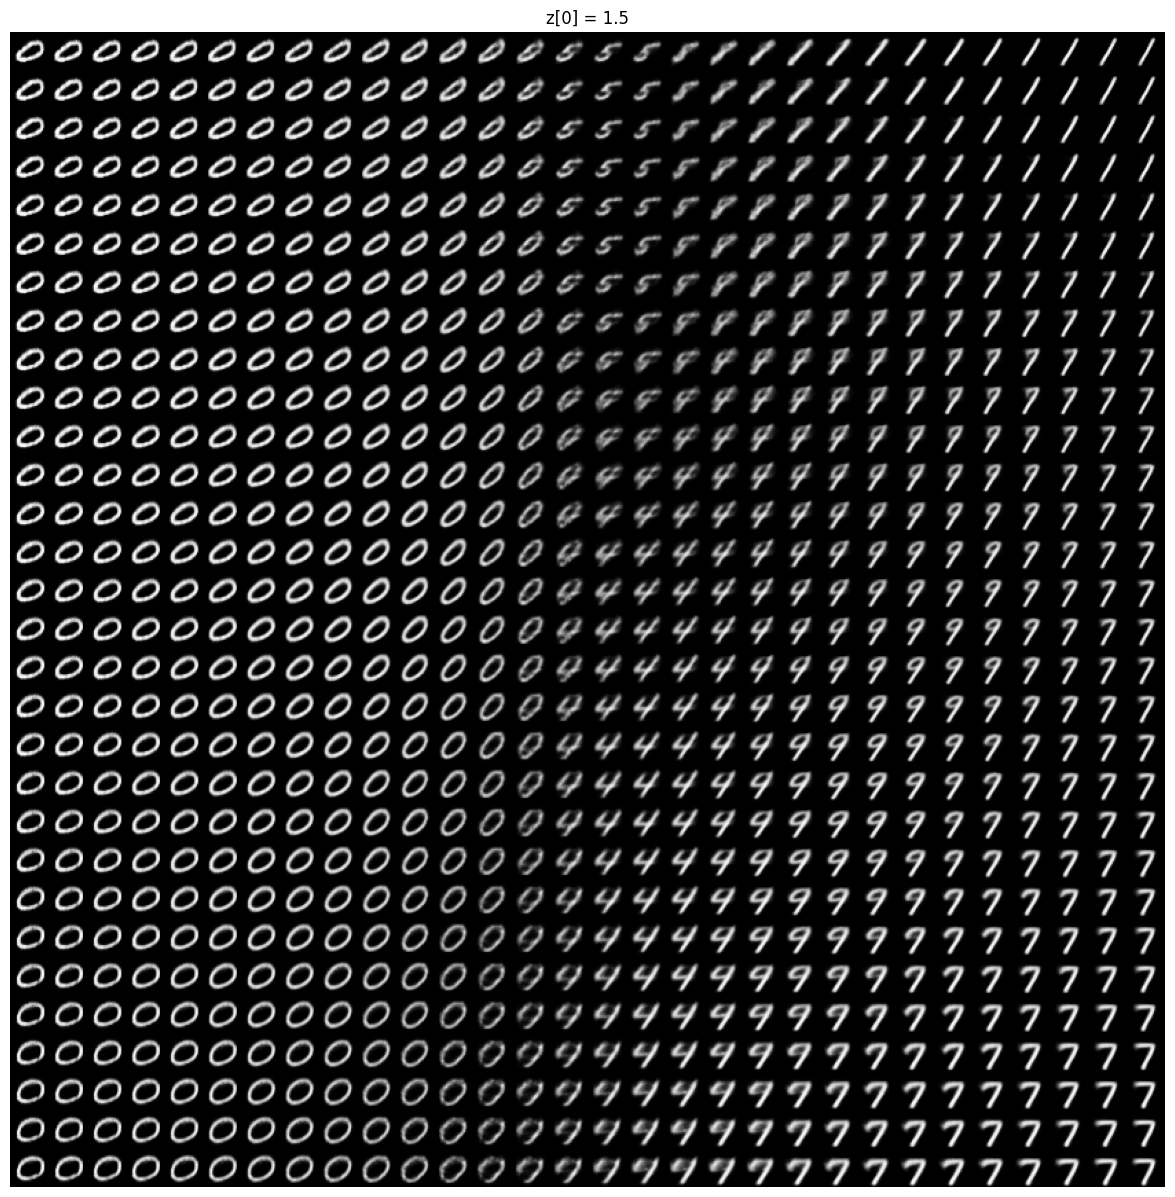

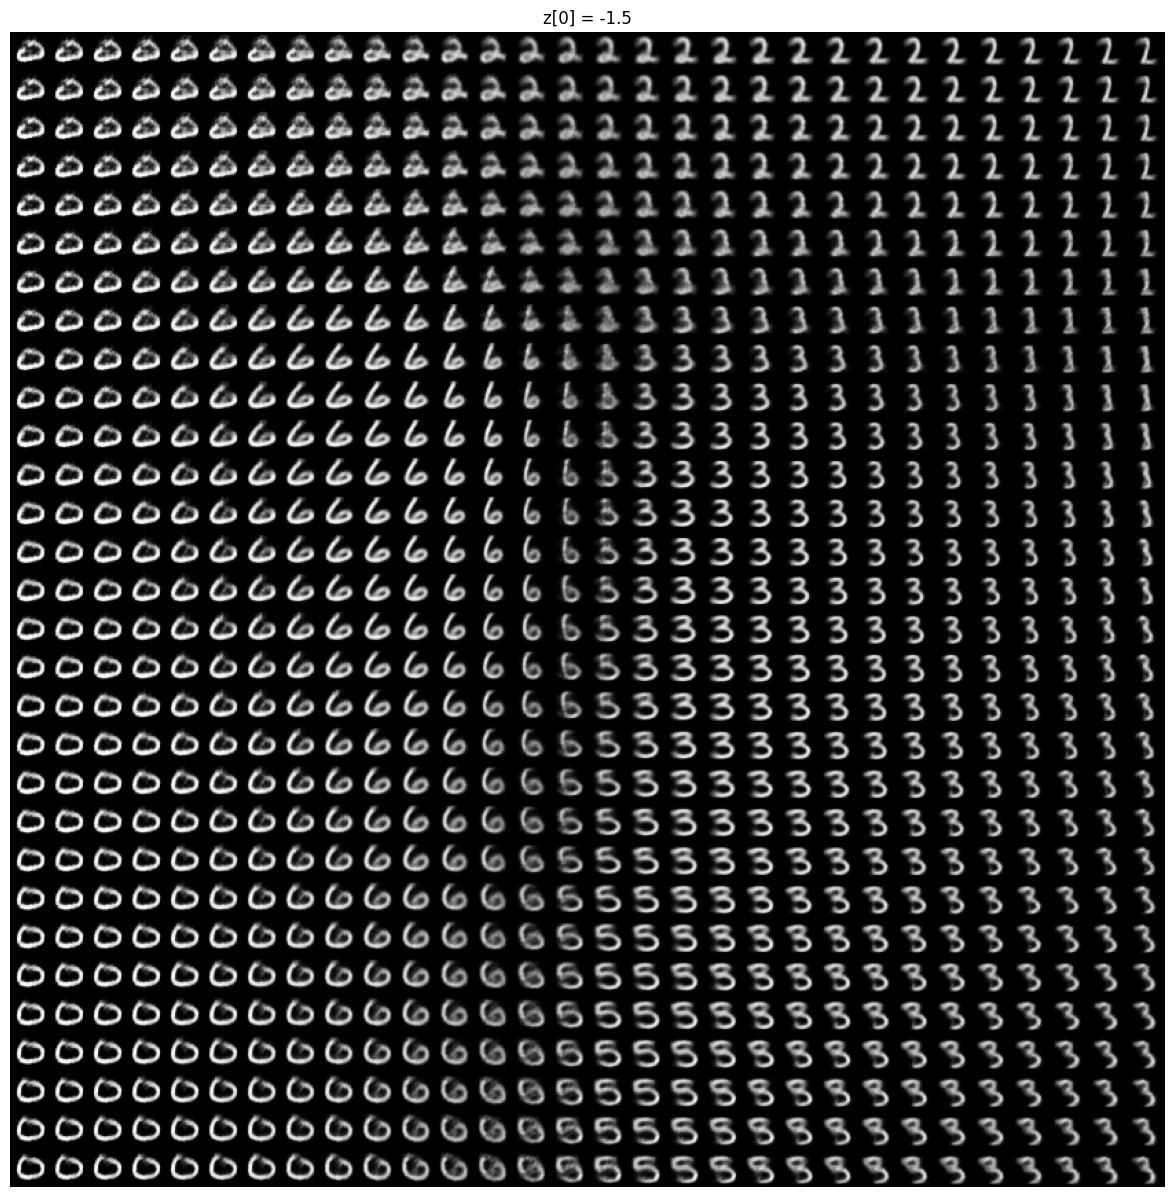

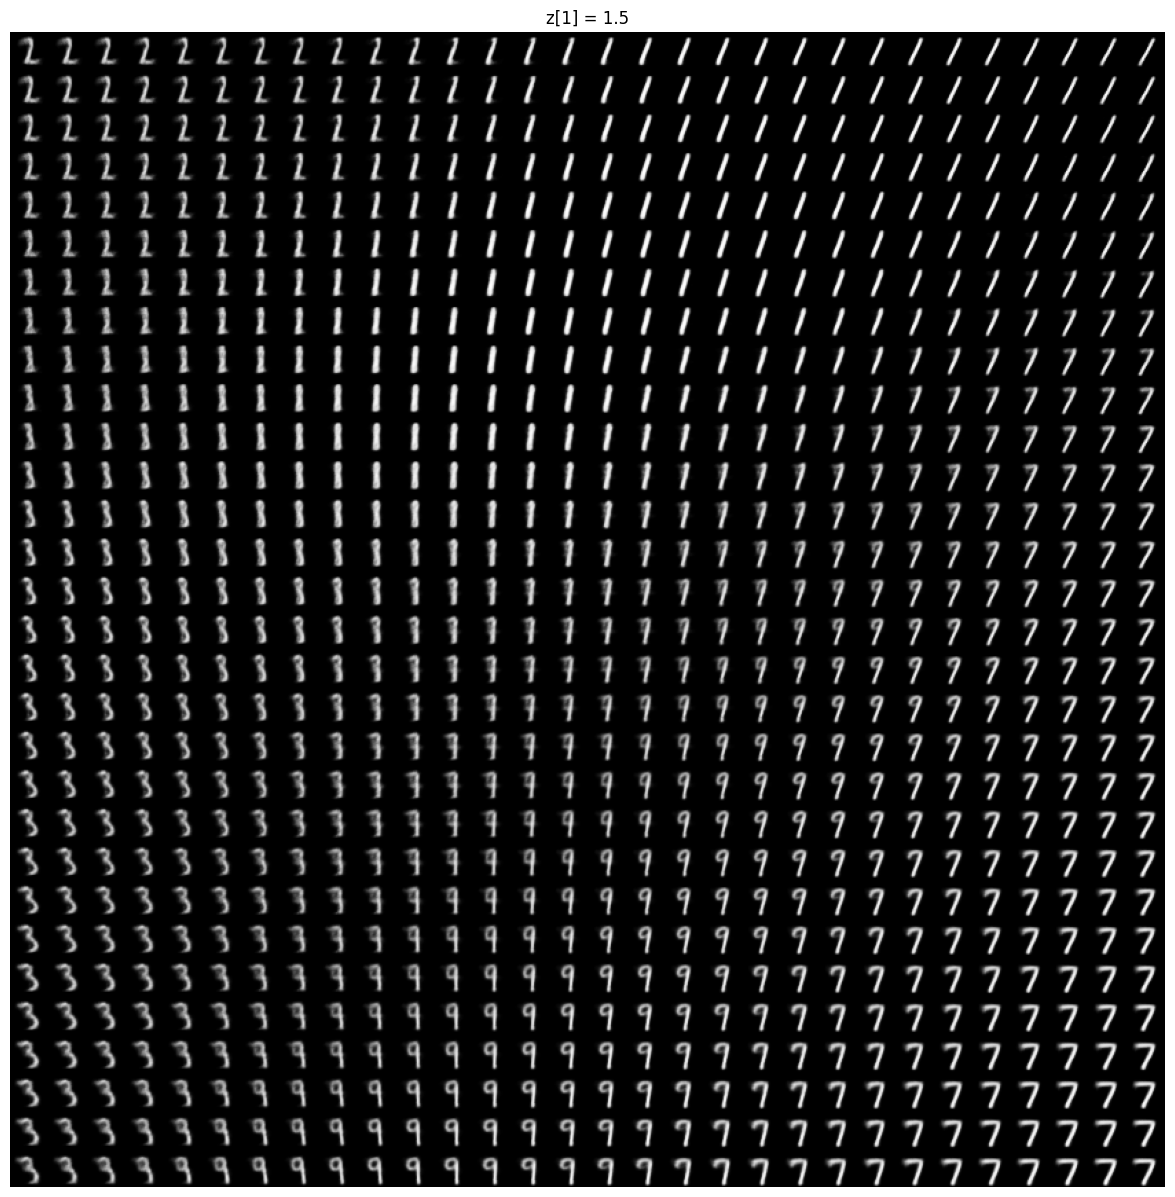

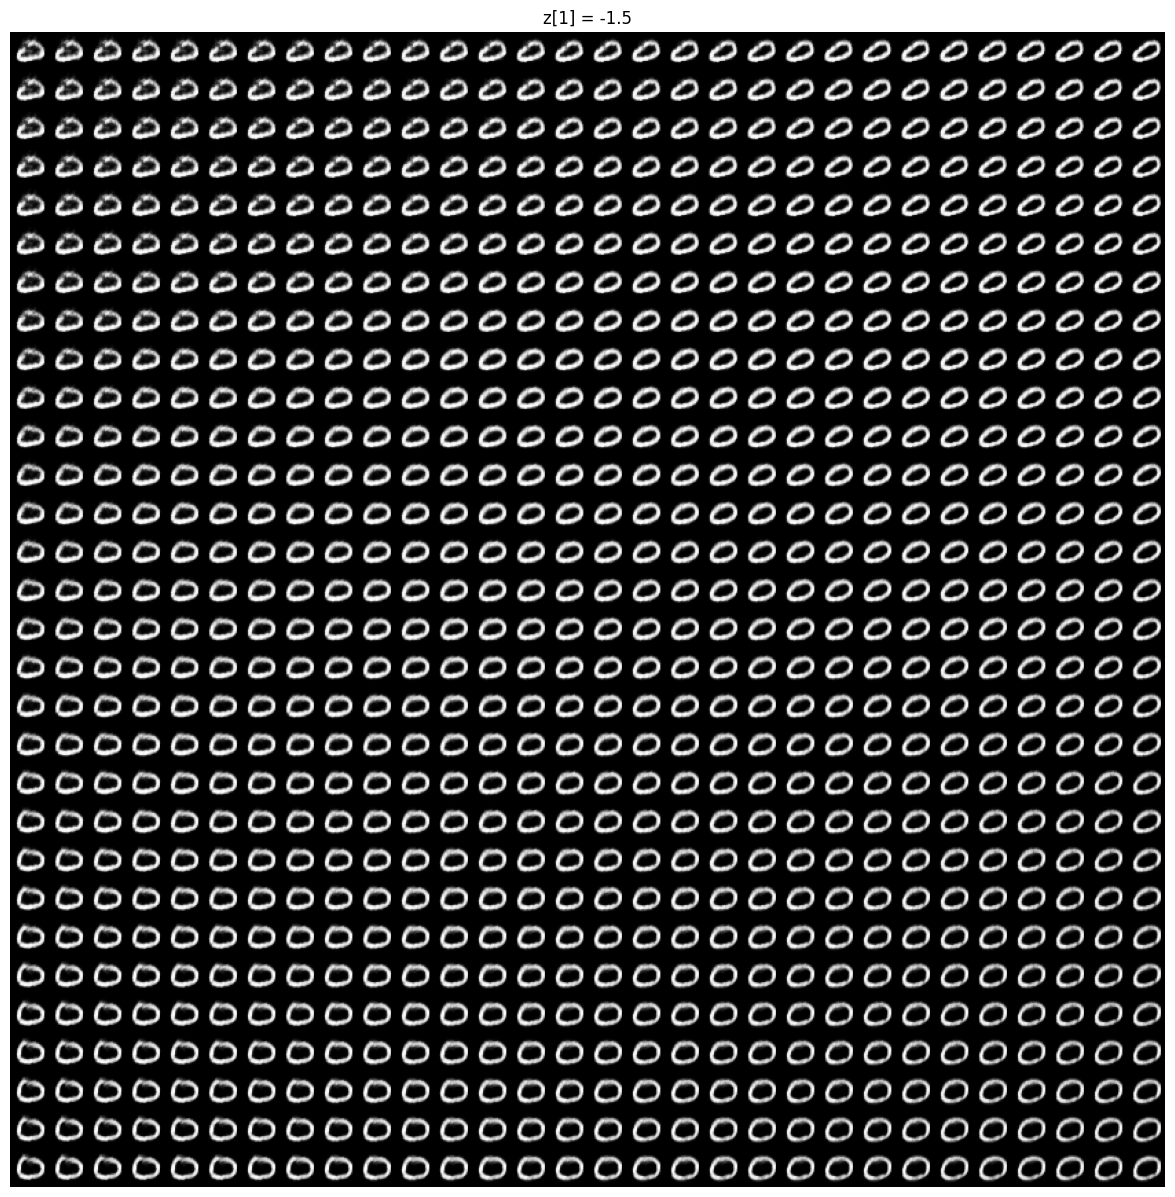

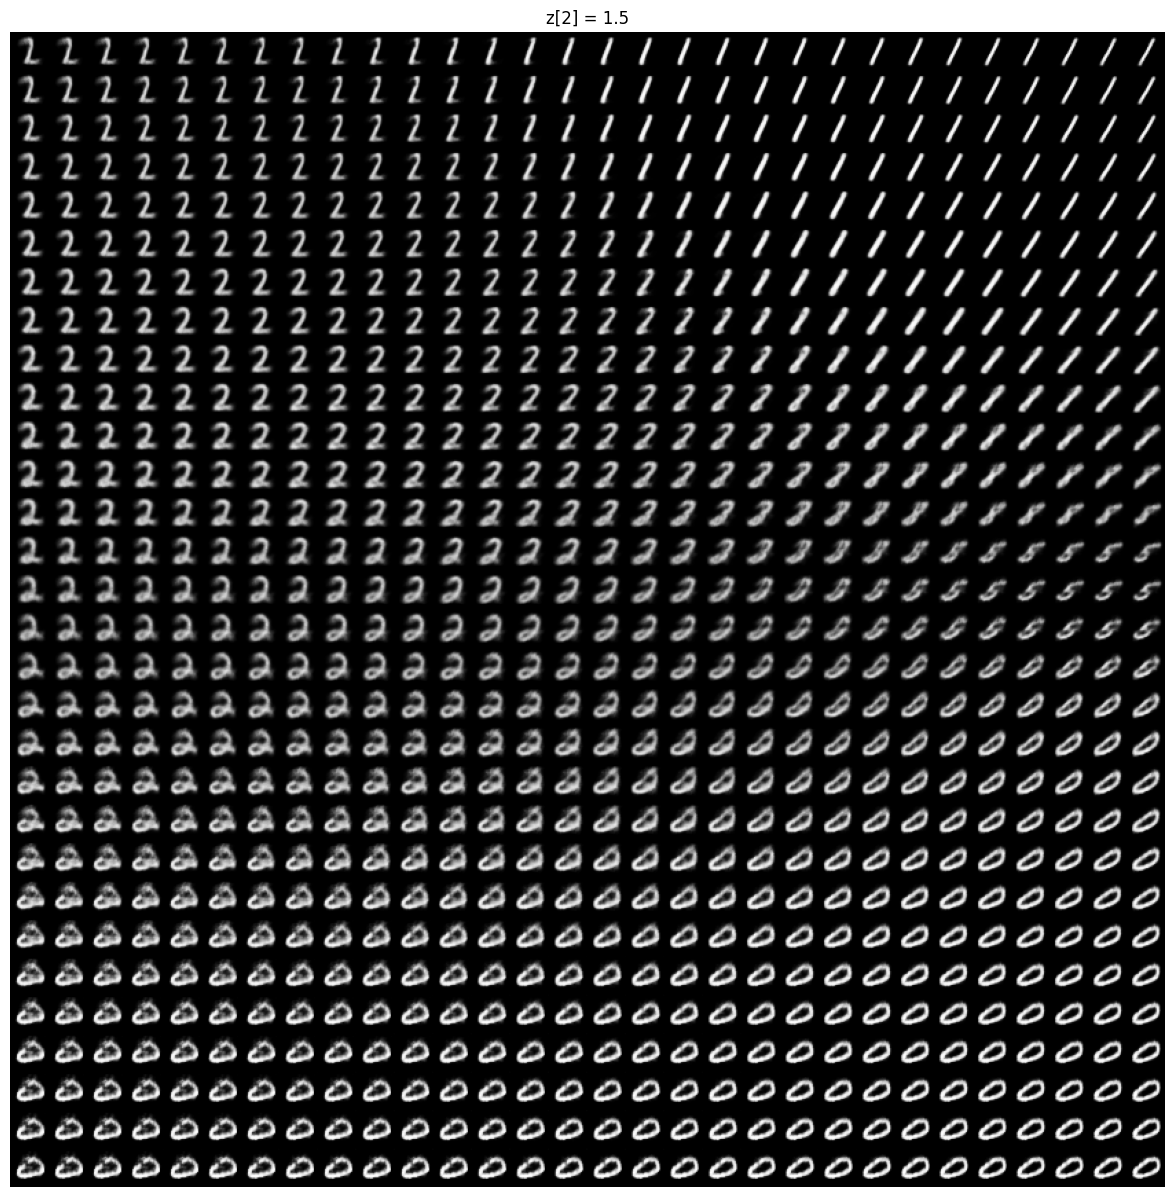

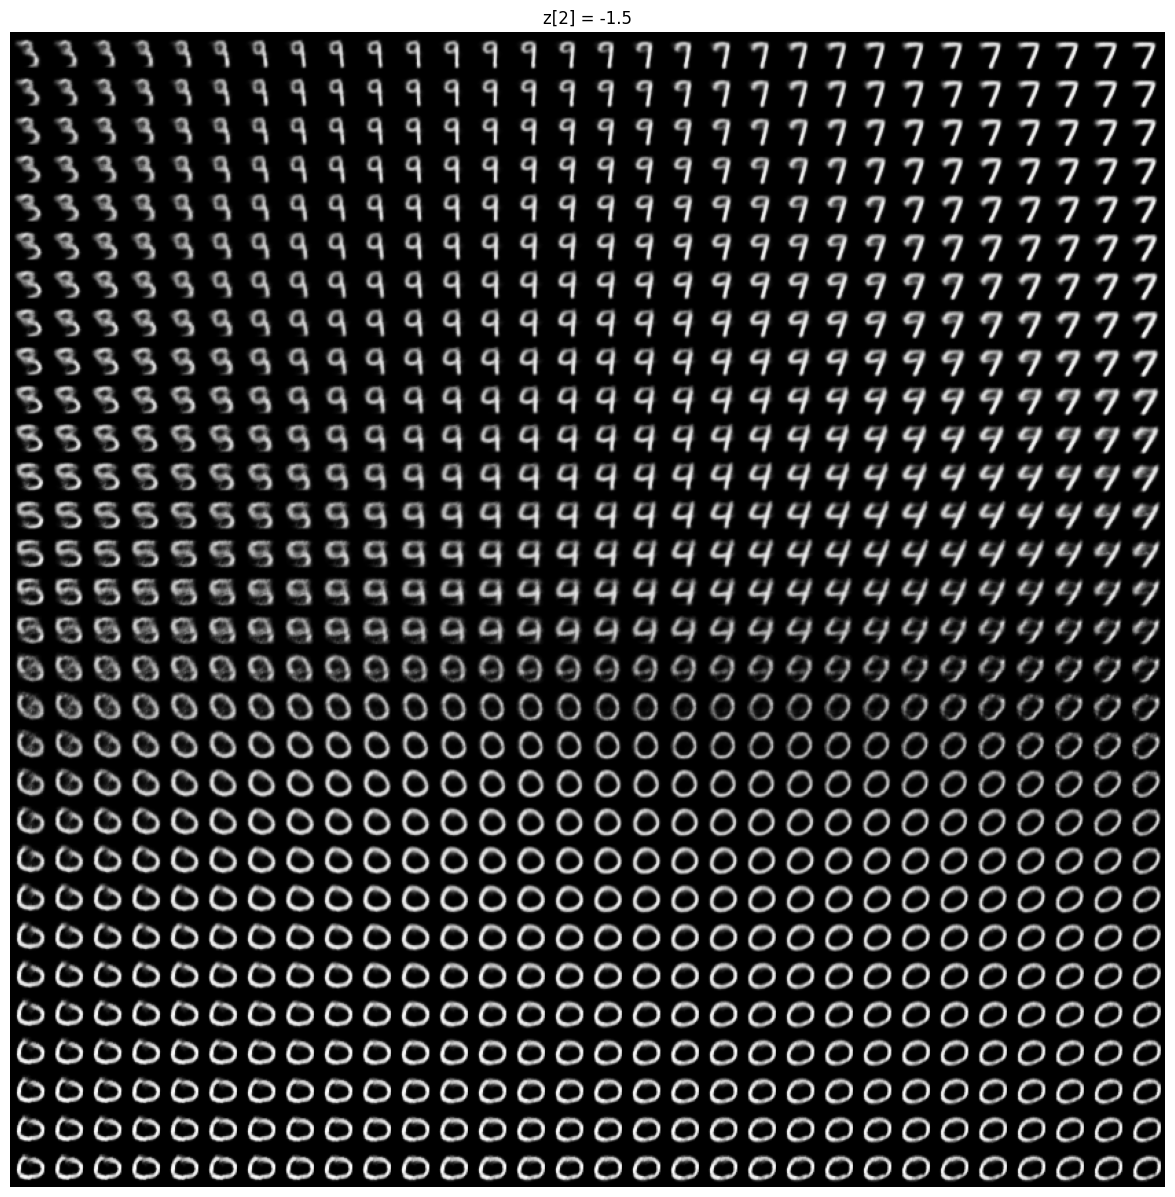

In [9]:
def plot_latent_plane(decoder, fixed_dim, fixed_value, n=30, scale=1.5):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))

    grid = np.linspace(-scale, scale, n)

    for i, yi in enumerate(grid[::-1]):
        for j, xi in enumerate(grid):

            z = np.zeros((1, 3))

            coords = [xi, yi]
            idx = 0

            for k in range(3):
                if k == fixed_dim:
                    z[0, k] = fixed_value
                else:
                    z[0, k] = coords[idx]
                    idx += 1

            x_decoded = decoder.predict(z, verbose=0)
            digit = x_decoded[0].reshape(28, 28)

            figure[
                i*digit_size:(i+1)*digit_size,
                j*digit_size:(j+1)*digit_size
            ] = digit

    plt.figure(figsize=(15, 15))
    plt.imshow(figure, cmap="gray")
    plt.title(f"z[{fixed_dim}] = {fixed_value}")
    plt.axis("off")
    plt.show()
    
c = 1.5

plot_latent_plane(vae.decoder, fixed_dim=0, fixed_value=+c)
plot_latent_plane(vae.decoder, fixed_dim=0, fixed_value=-c)

plot_latent_plane(vae.decoder, fixed_dim=1, fixed_value=+c)
plot_latent_plane(vae.decoder, fixed_dim=1, fixed_value=-c)

plot_latent_plane(vae.decoder, fixed_dim=2, fixed_value=+c)
plot_latent_plane(vae.decoder, fixed_dim=2, fixed_value=-c)

Display how the latent space clusters different digit classes

C:\Users\HP\AppData\Local\Temp\ipykernel_23232\4267897207.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


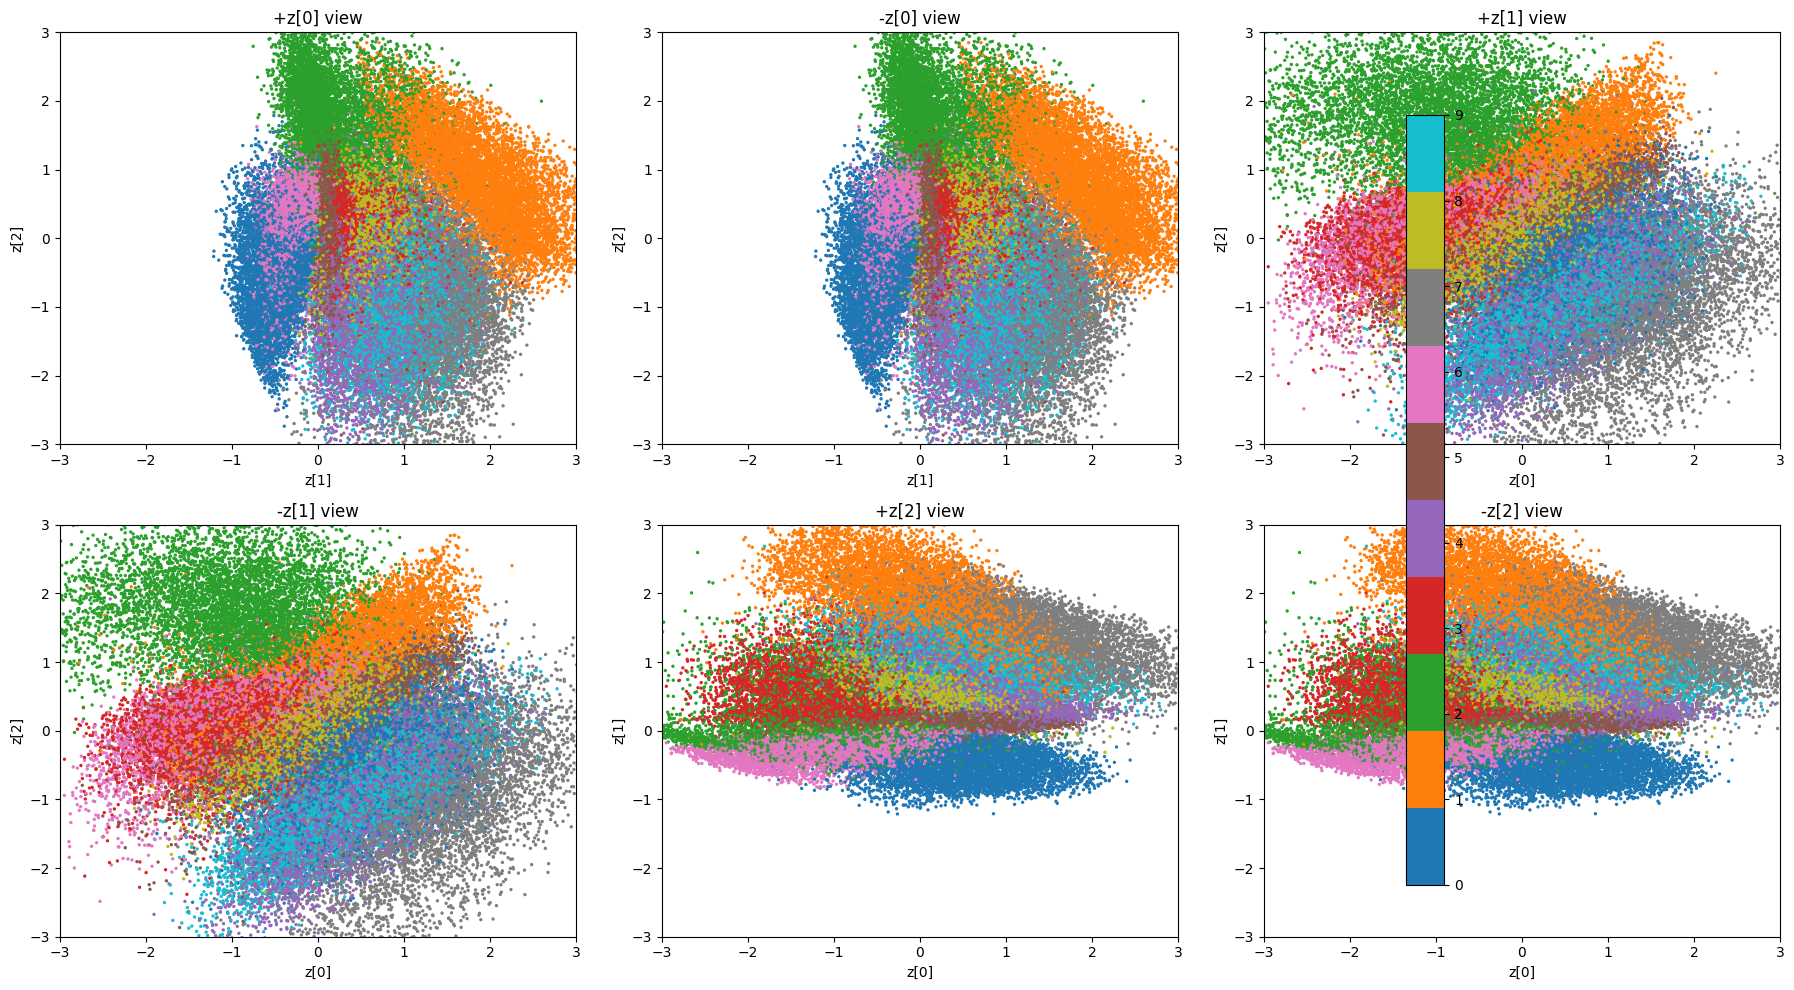

In [10]:
def plot_3d_latent_sides(x_train, labels, lim=3):
    _, _, z = vae.encoder.predict(x_train, verbose=0)
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))

    plots = [
        (1, 2, "z[1]", "z[2]", "+z[0] view"),
        (1, 2, "z[1]", "z[2]", "-z[0] view"),

        (0, 2, "z[0]", "z[2]", "+z[1] view"),
        (0, 2, "z[0]", "z[2]", "-z[1] view"),

        (0, 1, "z[0]", "z[1]", "+z[2] view"),
        (0, 1, "z[0]", "z[1]", "-z[2] view"),
    ]

    for ax, (i, j, xl, yl, title) in zip(axes.flat, plots):
        sc = ax.scatter(
            z[:, i],
            z[:, j],
            c=labels,
            s=2,
            cmap="tab10"
        )
        ax.set_xlabel(xl)
        ax.set_ylabel(yl)
        ax.set_title(title)
        ax.set_xlim(-lim, lim)
        ax.set_ylim(-lim, lim)

    fig.colorbar(sc, ax=axes.ravel().tolist())
    plt.tight_layout()
    plt.show()

plot_3d_latent_sides(mnist_digits, mnist_digit_labels)